# **Problem Statement**

Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit.

You are working as a data scientist with the analytics vertical of Scaler, focused on profiling the best companies and job positions to work for from the Scaler database. You are provided with the information for a segment of learners and tasked to cluster them on the basis of their job profile, company, and other features. Ideally, these clusters should have similar characteristics.

# **Downloading the Dataset**

In [ ]:
!wget "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/856/original/scaler_clustering.csv" -O scaler.csv

--2024-11-29 10:54:06--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/856/original/scaler_clustering.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 18.64.229.71, 18.64.229.91, 18.64.229.172, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|18.64.229.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24735965 (24M) [text/plain]
Saving to: ‘scaler.csv’

scaler.csv          100%[===================>]  23.59M   132MB/s    in 0.2s    

2024-11-29 10:54:06 (132 MB/s) - ‘scaler.csv’ saved [24735965/24735965]



**Basic checks on the data**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df= pd.read_csv("scaler.csv")
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [ ]:
df.shape

(205843, 7)

***Data Dictionary:***

*  ‘Unnamed 0’ - Index of the dataset
*  Email_hash - Anonymised Personal Identifiable Information (PII)
* Company_hash - This represents an anonymized identifier for the company, which is the current employer of the learner.
* orgyear - Employment start date
* CTC - Current CTC
* Job_position - Job profile in the company
* CTC_updated_year - Year in which CTC got updated (Yearly increments, Promotions)

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
company_hash,44
email_hash,0
orgyear,86
ctc,0
job_position,52564
ctc_updated_year,0


In [ ]:
df.nunique()

,0
Unnamed: 0,205843
company_hash,37299
email_hash,153443
orgyear,77
ctc,3360
job_position,1016
ctc_updated_year,7


**Regex to clean the strings in the data.**

In [ ]:
import re
def remove_special(str):
  new_str=re.sub('[^A-Za-z0-9]+','',str).lower().strip()
  return new_str

Drop unnecessary columns

In [ ]:
# Drop email_hash and unnamed features
df.drop(["Unnamed: 0","email_hash"],axis=1,inplace=True)
df.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year
0,atrgxnnt xzaxv,2016.0,1100000,Other,2020.0
1,qtrxvzwt xzegwgbb rxbxnta,2018.0,449999,FullStack Engineer,2019.0
2,ojzwnvwnxw vx,2015.0,2000000,Backend Engineer,2020.0
3,ngpgutaxv,2017.0,700000,Backend Engineer,2019.0
4,qxen sqghu,2017.0,1400000,FullStack Engineer,2019.0


In [ ]:
df

,company_hash,orgyear,ctc,job_position,ctc_updated_year
0,atrgxnnt xzaxv,2016.0,1100000,Other,2020.0
1,qtrxvzwt xzegwgbb rxbxnta,2018.0,449999,FullStack Engineer,2019.0
2,ojzwnvwnxw vx,2015.0,2000000,Backend Engineer,2020.0
3,ngpgutaxv,2017.0,700000,Backend Engineer,2019.0
4,qxen sqghu,2017.0,1400000,FullStack Engineer,2019.0
...,...,...,...,...,...
205838,vuurt xzw,2008.0,220000,NaN,2019.0
205839,husqvawgb,2017.0,500000,NaN,2020.0
205840,vwwgrxnt,2021.0,700000,NaN,2021.0
205841,zgn vuurxwvmrt,2019.0,5100000,NaN,2019.0


Check for nulls in the dataset.

In [ ]:
df['job_position'].isna().sum()

52564

In [ ]:
# Clean strings in company_hash and job_position
df["company_hash"]=df["company_hash"].apply(lambda x: remove_special(str(x)))
df["job_position"]=df["job_position"].apply(lambda x: remove_special(str(x)))

Cleaning and processing job_position feature

In [ ]:
df['job_position'].value_counts()[30:60]

,count
job_position,
intern,42
associatesoftwareengineer,35
engineer,29
student,25
softwaredevelopmentengineer,24
consultant,24
researchengineer,22
memberoftechnicalstaff,21
projectengineer,19


In [ ]:
df.duplicated().sum()

17624

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(188219, 5)

In [ ]:
# Removing rows that do not have company or job position details
df = df[~((df["company_hash"]=="")|(df["job_position"]==""))]
df.shape

(188126, 5)

In [ ]:
df.isna().sum()

,0
company_hash,0
orgyear,86
ctc,0
job_position,0
ctc_updated_year,0


In [ ]:
# Filling null values in orgyear with the median values based on company_hash

df['orgyear']=df['orgyear'].fillna(df.groupby("company_hash")["orgyear"].transform('median'))
df['orgyear'].isna().sum()

<ipython-input-100-4d1157e3479b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['orgyear']=df['orgyear'].fillna(df.groupby("company_hash")["orgyear"].transform('median'))


26

In [ ]:
# Removing rows where orgyear is null even after filling with median

df= df[~(df['orgyear'].isna())]
df.isna().sum()

,0
company_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0


In [ ]:
df['orgyear'].value_counts()

,count
orgyear,
2018.0,22151
2016.0,21476
2017.0,21320
2015.0,19608
2019.0,18545
2014.0,16091
2013.0,12053
2020.0,10429
2012.0,10257


In [ ]:
df['orgyear'].value_counts().sort_index(ascending=True)

,count
orgyear,
0.0,17
1.0,2
2.0,3
3.0,6
4.0,1
5.0,2
6.0,2
38.0,1
83.0,1


From value_counts , can see that there are outliers .

In [ ]:
df.shape

(188100, 5)

**Outlier Treatment using IQR**

In [ ]:
# Removing outliers from orgyear using IQR.
q1= df['orgyear'].quantile(0.25)
q3=df['orgyear'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['orgyear']>=lower_bound) & (df['orgyear']<=upper_bound)]
df.shape

(180380, 5)

In [ ]:
df.isna().sum()

,0
company_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0


In [ ]:
df['ctc'].value_counts().sort_index(ascending=True)

,count
ctc,
2,1
6,1
14,1
15,1
16,1
...,...
199990000,2
200000000,362
250000000,1


In [ ]:
#Removing outliers from ctc using IQR
q1= df['ctc'].quantile(0.25)
q3=df['ctc'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['ctc']>=lower_bound) & (df['ctc']<=upper_bound)]
df.shape

(168960, 5)

In [ ]:
df.isna().sum()

,0
company_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0


In [ ]:
df['job_position'].isna().sum()

0

In [ ]:
df

,company_hash,orgyear,ctc,job_position,ctc_updated_year
0,atrgxnntxzaxv,2016.0,1100000,other,2020.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0
...,...,...,...,...,...
205836,mvqwrvjo,2011.0,2250000,nan,2019.0
205838,vuurtxzw,2008.0,220000,nan,2019.0
205839,husqvawgb,2017.0,500000,nan,2020.0
205840,vwwgrxnt,2021.0,700000,nan,2021.0


Checking for nan strings and converting them to NaN

In [ ]:
#We see some 'nan's in job_position
df.loc[df['job_position']=='nan','job_position']=np.nan

In [ ]:
df

,company_hash,orgyear,ctc,job_position,ctc_updated_year
0,atrgxnntxzaxv,2016.0,1100000,other,2020.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0
...,...,...,...,...,...
205836,mvqwrvjo,2011.0,2250000,NaN,2019.0
205838,vuurtxzw,2008.0,220000,NaN,2019.0
205839,husqvawgb,2017.0,500000,NaN,2020.0
205840,vwwgrxnt,2021.0,700000,NaN,2021.0


In [ ]:
df['job_position'].isna().sum()

39850

In [ ]:
df['company_hash'].value_counts()

,count
company_hash,
nvnvwgzohrnvzwjotqcxwto,4111
xzegojo,2910
vbvkgz,2227
wgszxkvzn,2114
vwwtznhqt,1998
...,...
nvrrtznnvnngg,1
wvwvgogrhnxgzo,1
bhzsxtzsxzttqxzsucnrna,1


Mask companies that have very low occurances.

In [ ]:
#Masking companies with less count as Others
df['company_hash']=df['company_hash'].mask(df['company_hash'].map(df['company_hash'].value_counts())<5,'others')

In [ ]:
df['company_hash'].value_counts()

,count
company_hash,
others,43118
nvnvwgzohrnvzwjotqcxwto,4111
xzegojo,2910
vbvkgz,2227
wgszxkvzn,2114
...,...
tzuvqvaxsb,5
bjbgztjpvqbv,5
thqgexzoxnogrhnxgzoxzaxv,5


In [ ]:
df.duplicated().sum()

19617

In [ ]:
df.shape

(168960, 5)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(149343, 5)

Correcting orgyear values to match current year that are pointing to future years.

In [ ]:
df[df['orgyear']>=2024].value_counts()

company_hash             orgyear  ctc      job_position           ctc_updated_year
hztburgjta               2024.0   180000   backendengineer        2021.0              1
xzntqcxtfmxn             2024.0   200000   backendengineer        2020.0              1
vau                      2024.0   80000    other                  2020.0              1
vbvkgz                   2024.0   1400000  frontendengineer       2021.0              1
xbvonhatzn               2024.0   110000   frontendengineer       2021.0              1
                                           other                  2021.0              1
                         2025.0   300000   other                  2021.0              1
xzegojo                  2025.0   360000   other                  2020.0              1
xzntqcxtfmxn             2024.0   400000   backendengineer        2020.0              1
ntwybvyxzaqv             2024.0   250000   frontendengineer       2021.0              1
ywrntwyzgrgsxto          2024.0   220000   supportengineer        2021.0              1
yxptbtootzstq            2024.0   300000   androidengineer        2021.0              1
zgnvuurxwvmrtvwwghzn     2024.0   919999   engineeringleadership  2021.0              1
                         2025.0   56000    backendengineer        2021.0              1
zgzt                     2024.0   200000   other                  2021.0              1
                         2025.0   1200000  fullstackengineer      2021.0              1
uyvqbtvoj                2024.0   1800000  datascientist          2019.0              1
staxsxnvr                2024.0   1320000  backendengineer        2020.0              1
otretburgjta             2024.0   200000   cofounder              2021.0              1
others                   2025.0   150000   devopsengineer         2021.0              1
                                  120000   fullstackengineer      2018.0              1
                                  42000    frontendengineer       2021.0              1
                         2024.0   1400000  fullstackengineer      2019.0              1
                                  900000   other                  2021.0              1
                                  700000   fullstackengineer      2021.0              1
                                  450000   fullstackengineer      2020.0              1
                                  220000   fullstackengineer      2021.0              1
                                  60000    frontendengineer       2021.0              1
onhatznvnbzzxnvrrvyvmva  2024.0   1200000  other                  2021.0              1
                                           fullstackengineer      2021.0              1
onhatzn                  2025.0   1000000  researchengineers      2020.0              1
                         2024.0   100000   other                  2021.0              1
nyghsynfgqpo             2024.0   850000   frontendengineer       2021.0              1
zvz                      2024.0   1400000  engineeringleadership  2021.0              1
Name: count, dtype: int64

In [ ]:
#changing orgyear above 2024 to 2024
df.loc[df['orgyear']>=2024,'orgyear']=2024

In [ ]:
df[df['orgyear']>2024].value_counts()

,,,,,count
company_hash,orgyear,ctc,job_position,ctc_updated_year,


Duplicate check and drop them .

In [ ]:
# checking for duplicates
df.duplicated().sum()

1

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(149342, 5)

In [ ]:
#creating a new feature "years of experience"

df['years_of_experience']=2024-df['orgyear']
df

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience
0,atrgxnntxzaxv,2016.0,1100000,other,2020.0,8.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0
...,...,...,...,...,...,...
205836,mvqwrvjo,2011.0,2250000,NaN,2019.0,13.0
205838,vuurtxzw,2008.0,220000,NaN,2019.0,16.0
205839,husqvawgb,2017.0,500000,NaN,2020.0,7.0
205840,vwwgrxnt,2021.0,700000,NaN,2021.0,3.0


In [ ]:
# checking ctc_updated_year feature

df['ctc_updated_year'].value_counts()

,count
ctc_updated_year,
2019.0,49095
2021.0,44079
2020.0,36598
2017.0,6488
2018.0,5760
2016.0,4741
2015.0,2581


In [ ]:
df[df['ctc_updated_year']<df['orgyear']].value_counts()


company_hash   orgyear  ctc      job_position               ctc_updated_year  years_of_experience
adwntwyzgrgsj  2016.0   300000   fullstackengineer          2015.0            8.0                    1
uyvqbtvoj      2024.0   1800000  datascientist              2019.0            0.0                    1
uvjuvr         2018.0   2000000  engineeringintern          2016.0            6.0                    1
uvqtdtr        2018.0   1200000  other                      2016.0            6.0                    1
uvqvrrtragno   2017.0   1200000  datascientist              2016.0            7.0                    1
                                                                                                    ..
others         2017.0   60000    cofounder                  2015.0            7.0                    1
                                 graduateresearchassistant  2016.0            7.0                    1
                                 other                      2015.0            7.0                    1
                                                            2016.0            7.0                    1
zxwtvwnxbxkt   2021.0   1150000  datascientist              2019.0            3.0                    1
Name: count, Length: 4337, dtype: int64

In [ ]:
# update the ctc_updated_year with orgyear where ctc_updated_year is less than org year
df.loc[df['ctc_updated_year']<df['orgyear'],'ctc_updated_year']=df['orgyear']

In [ ]:

df[df['ctc_updated_year']<df['orgyear']].value_counts()


,,,,,,count
company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,


In [ ]:
df.isna().sum()

,0
company_hash,0
orgyear,0
ctc,0
job_position,34039
ctc_updated_year,0
years_of_experience,0


In [ ]:
df.loc[df['job_position'].isna()]

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience
8,utqoxontznojontbo,2020.0,450000,NaN,2020.0,4.0
9,others,2019.0,360000,NaN,2019.0,5.0
12,mvqwrvjowgqugqvntmvzpxzs,2020.0,800000,NaN,2020.0,4.0
17,puxn,2020.0,1400000,NaN,2020.0,4.0
18,mvlvlexzotqc,2018.0,100000,NaN,2021.0,6.0
...,...,...,...,...,...,...
205836,mvqwrvjo,2011.0,2250000,NaN,2019.0,13.0
205838,vuurtxzw,2008.0,220000,NaN,2019.0,16.0
205839,husqvawgb,2017.0,500000,NaN,2020.0,7.0
205840,vwwgrxnt,2021.0,700000,NaN,2021.0,3.0


In [ ]:
#update 'job_position' as 'Others' where ever it is null
df.loc[df['job_position'].isna(),'job_position']='others'

In [ ]:
df.shape

(149342, 6)

In [ ]:
df.isna().sum()

,0
company_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0
years_of_experience,0


In [ ]:
df.duplicated().sum()

997

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(148345, 6)

In [ ]:
df.describe()

,orgyear,ctc,ctc_updated_year,years_of_experience
count,148345.000000,1.483450e+05,148345.000000,148345.000000
mean,2015.462479,1.126491e+06,2019.606364,8.537521
std,3.301479,7.420388e+05,1.339959,3.301479
min,2006.000000,2.000000e+00,2015.000000,0.000000
25%,2013.000000,5.700000e+05,2019.000000,6.000000
50%,2016.000000,9.500000e+05,2020.000000,8.000000
75%,2018.000000,1.550000e+06,2021.000000,11.000000
max,2024.000000,3.330000e+06,2024.000000,18.000000


Observations:

1. Data is collected from the year 2006 .
2. Max years of experience of the learners is 18 years.

In [ ]:
# change Others and other to others in job_position
df.loc[df['job_position']=='Others','job_position']='others'
df.loc[df['job_position']=='other','job_position']='others'

In [ ]:
df

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0
...,...,...,...,...,...,...
205836,mvqwrvjo,2011.0,2250000,others,2019.0,13.0
205838,vuurtxzw,2008.0,220000,others,2019.0,16.0
205839,husqvawgb,2017.0,500000,others,2020.0,7.0
205840,vwwgrxnt,2021.0,700000,others,2021.0,3.0


In [ ]:
df.duplicated().sum()

4714

In [ ]:
pd.set_option('display.max_rows', 1000)
df.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0


In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(143631, 6)

# **Manual Clustering :**

# **Manual Clustering Based on Company, Job_Position and Years_Of_experience**

In [ ]:
# group data based on years_of_experience, job_position and company_hash
grouped_df_cjy = df.groupby(['years_of_experience', 'job_position', 'company_hash'])['ctc'].describe()
grouped_df_cjy.head(10)

count  \
years_of_experience job_position          company_hash                  
0.0                 androidengineer       yxptbtootzstq           1.0   
                    backendengineer       hztburgjta              1.0   
                                          staxsxnvr               1.0   
                                          xzntqcxtfmxn            2.0   
                                          zgnvuurxwvmrtvwwghzn    1.0   
                    cofounder             otretburgjta            1.0   
                    datascientist         uyvqbtvoj               1.0   
                    devopsengineer        others                  1.0   
                    engineeringleadership zgnvuurxwvmrtvwwghzn    1.0   
                                          zvz                     1.0   

                                                                     mean  \
years_of_experience job_position          company_hash                      
0.0                 androidengineer       yxptbtootzstq          300000.0   
                    backendengineer       hztburgjta             180000.0   
                                          staxsxnvr             1320000.0   
                                          xzntqcxtfmxn           300000.0   
                                          zgnvuurxwvmrtvwwghzn    56000.0   
                    cofounder             otretburgjta           200000.0   
                    datascientist         uyvqbtvoj             1800000.0   
                    devopsengineer        others                 150000.0   
                    engineeringleadership zgnvuurxwvmrtvwwghzn   919999.0   
                                          zvz                   1400000.0   

                                                                          std  \
years_of_experience job_position          company_hash                          
0.0                 androidengineer       yxptbtootzstq                   NaN   
                    backendengineer       hztburgjta                      NaN   
                                          staxsxnvr                       NaN   
                                          xzntqcxtfmxn          141421.356237   
                                          zgnvuurxwvmrtvwwghzn            NaN   
                    cofounder             otretburgjta                    NaN   
                    datascientist         uyvqbtvoj                       NaN   
                    devopsengineer        others                          NaN   
                    engineeringleadership zgnvuurxwvmrtvwwghzn            NaN   
                                          zvz                             NaN   

                                                                      min  \
years_of_experience job_position          company_hash                      
0.0                 androidengineer       yxptbtootzstq          300000.0   
                    backendengineer       hztburgjta             180000.0   
                                          staxsxnvr             1320000.0   
                                          xzntqcxtfmxn           200000.0   
                                          zgnvuurxwvmrtvwwghzn    56000.0   
                    cofounder             otretburgjta           200000.0   
                    datascientist         uyvqbtvoj             1800000.0   
                    devopsengineer        others                 150000.0   
                    engineeringleadership zgnvuurxwvmrtvwwghzn   919999.0   
                                          zvz                   1400000.0   

                                                                      25%  \
years_of_experience job_position          company_hash                      
0.0                 androidengineer       yxptbtootzstq          300000.0   
                    backendengineer       hztburgjta             180000.0   
                                          staxsxnvr     

In [ ]:
df_cjy= df.merge(grouped_df_cjy, on=['years_of_experience', 'job_position', 'company_hash'],how='left')
df_cjy.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,count,mean,std,min,25%,50%,75%,max
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,1.0,1.100000e+06,NaN,1100000.0,1100000.0,1100000.0,1100000.0,1100000.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,7.0,7.742856e+05,250922.324350,449999.0,610000.0,750000.0,900000.0,1200000.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,1.0,2.000000e+06,NaN,2000000.0,2000000.0,2000000.0,2000000.0,2000000.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,7.0,1.158571e+06,404780.951933,700000.0,825000.0,1200000.0,1405000.0,1750000.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,1.0,1.400000e+06,NaN,1400000.0,1400000.0,1400000.0,1400000.0,1400000.0


Creating designation based on the salary they are getting in their respective company

In [ ]:
def segment(a,b_50,c_75):
  if a<=b_50:
    return 3
  elif a>b_50 and a<=c_75:
    return 2
  else:
    return 1

In [ ]:
df.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0


In [ ]:
df_cjy['designation']=df_cjy.apply(lambda x: segment(x['ctc'],x['50%'],x['75%']),axis=1)
df_cjy.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,count,mean,std,min,25%,50%,75%,max,designation
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,1.0,1.100000e+06,NaN,1100000.0,1100000.0,1100000.0,1100000.0,1100000.0,3
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,7.0,7.742856e+05,250922.324350,449999.0,610000.0,750000.0,900000.0,1200000.0,3
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,1.0,2.000000e+06,NaN,2000000.0,2000000.0,2000000.0,2000000.0,2000000.0,3
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,7.0,1.158571e+06,404780.951933,700000.0,825000.0,1200000.0,1405000.0,1750000.0,3
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,1.0,1.400000e+06,NaN,1400000.0,1400000.0,1400000.0,1400000.0,1400000.0,3


In [ ]:
df_cjy['designation'].value_counts(normalize=True)*100

,proportion
designation,
3,66.042846
1,21.619985
2,12.337170


# **Manual Clustering Based on Company and Job_Position**

In [ ]:
# group data based on job_position and company_hash
grouped_df_cj=df.groupby(['job_position','company_hash'])['ctc'].describe()
grouped_df_cj.head(10)

,,count,mean,std,min,25%,50%,75%,max
job_position,company_hash,,,,,,,,
abapdeveloper,others,1.0,500000.0,NaN,500000.0,500000.0,500000.0,500000.0,500000.0
account,zgnvuurxwvmrtvwwghzn,1.0,2000000.0,NaN,2000000.0,2000000.0,2000000.0,2000000.0,2000000.0
administrativeclerk,others,1.0,500000.0,NaN,500000.0,500000.0,500000.0,500000.0,500000.0
administrator,others,1.0,380000.0,NaN,380000.0,380000.0,380000.0,380000.0,380000.0
advisor,exo,1.0,360000.0,NaN,360000.0,360000.0,360000.0,360000.0,360000.0
advisorysoftwareengineer,others,1.0,1290000.0,NaN,1290000.0,1290000.0,1290000.0,1290000.0,1290000.0
advisorysystemanalyat,xmb,1.0,680000.0,NaN,680000.0,680000.0,680000.0,680000.0,680000.0
agencycollectionmanager,others,1.0,360000.0,NaN,360000.0,360000.0,360000.0,360000.0,360000.0
agroupchatapplication,others,1.0,500000.0,NaN,500000.0,500000.0,500000.0,500000.0,500000.0


Merging the grouped_cj with df based on company and job_postion

In [ ]:
df_cj=df.merge(grouped_df_cj,on=['job_position','company_hash'],how='left')
df_cj.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,count,mean,std,min,25%,50%,75%,max
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,2.0,1.085000e+06,21213.203436,1070000.0,1077500.0,1085000.0,1092500.0,1100000.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,25.0,9.882000e+05,487499.789590,300000.0,600000.0,850000.0,1380000.0,2000000.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,3.0,1.983333e+06,525198.375220,1450000.0,1725000.0,2000000.0,2250000.0,2500000.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,24.0,1.416667e+06,545341.270627,520000.0,1047500.0,1375000.0,1792500.0,2600000.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,3.0,8.466667e+05,480138.868801,540000.0,570000.0,600000.0,1000000.0,1400000.0


Creating class based on the salary they are getting in their respective company

In [ ]:
df_cj['class']=df_cj.apply(lambda x: segment(x['ctc'],x['50%'],x['75%']),axis=1)
df_cj.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,count,mean,std,min,25%,50%,75%,max,class
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,2.0,1.085000e+06,21213.203436,1070000.0,1077500.0,1085000.0,1092500.0,1100000.0,1
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,25.0,9.882000e+05,487499.789590,300000.0,600000.0,850000.0,1380000.0,2000000.0,3
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,3.0,1.983333e+06,525198.375220,1450000.0,1725000.0,2000000.0,2250000.0,2500000.0,3
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,24.0,1.416667e+06,545341.270627,520000.0,1047500.0,1375000.0,1792500.0,2600000.0,3
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,3.0,8.466667e+05,480138.868801,540000.0,570000.0,600000.0,1000000.0,1400000.0,1


In [ ]:
df_cj['class'].value_counts(normalize=True)*100

,proportion
class,
3,56.401473
1,24.372872
2,19.225655


In [ ]:
# job_position that has highest_class
df_cj[df_cj['class']==1][['job_position','ctc']].groupby('job_position')['ctc'].describe().sort_values(by=['count','mean'],ascending=False).head(10)


,count,mean,std,min,25%,50%,75%,max
job_position,,,,,,,,
others,10408.0,1.897610e+06,702854.115232,50000.0,1370000.0,1850000.0,2500000.0,3330000.0
backendengineer,8275.0,2.048395e+06,693553.460515,12000.0,1500000.0,2000000.0,2600000.0,3330000.0
fullstackengineer,4836.0,1.826031e+06,692341.866726,59000.0,1300000.0,1720000.0,2330000.0,3330000.0
frontendengineer,2015.0,1.655688e+06,632196.773290,90000.0,1200000.0,1550000.0,2000000.0,3300000.0
qaengineer,1268.0,1.384218e+06,631517.411210,65000.0,900000.0,1250000.0,1700000.0,3300000.0
datascientist,1028.0,1.985017e+06,660657.952259,115000.0,1600000.0,2000000.0,2452500.0,3310000.0
sdet,997.0,1.537592e+06,718557.169574,140000.0,900000.0,1400000.0,2000000.0,3329999.0
devopsengineer,929.0,1.740286e+06,629445.066247,56000.0,1300000.0,1650000.0,2100000.0,3300000.0
androidengineer,919.0,1.765926e+06,649457.401094,14000.0,1300000.0,1664000.0,2200000.0,3300000.0


# **Manual Clustering based on company**

In [ ]:
# group data based on company
grouped_df_c=df.groupby(['company_hash'])['ctc'].describe()
grouped_df_c.head(10)

,count,mean,std,min,25%,50%,75%,max
company_hash,,,,,,,,
aaqxctzavnvowxtzwtovzvrjnxwoucnrna,7.0,6.114286e+05,362373.130508,360000.0,430000.0,500000.0,580000.0,1400000.0
abwavnvojontb,5.0,7.320000e+05,43817.804600,700000.0,700000.0,700000.0,780000.0,780000.0
adwntwyzgrgsj,245.0,7.420204e+05,510138.354048,32000.0,400000.0,570000.0,930000.0,3200000.0
adwntwyzgrgsxto,126.0,7.016111e+05,376552.552020,100000.0,401750.0,600000.0,900000.0,2350000.0
agdutq,6.0,1.666667e+06,686051.504383,800000.0,1400000.0,1400000.0,2225000.0,2500000.0
aggartmrhtxzzgcvnxgzo,9.0,5.511111e+05,212805.336190,360000.0,450000.0,500000.0,540000.0,1000000.0
aghmnzhn,18.0,1.221667e+06,678883.165899,500000.0,701250.0,875000.0,1800000.0,2400000.0
agnoihvqto,19.0,7.230526e+05,318784.753867,340000.0,485000.0,700000.0,900000.0,1600000.0
agnut,8.0,1.653750e+06,574927.014001,1230000.0,1350000.0,1425000.0,1687500.0,3000000.0


Merge group_df_c with df

In [ ]:
df_c=df.merge(grouped_df_c,on=['company_hash'],how='left')
df_c.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,count,mean,std,min,25%,50%,75%,max
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,9.0,1.115667e+06,458111.885897,500000.0,800000.0,1070000.0,1500000.0,1771000.0
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,377.0,1.065469e+06,636791.154939,10000.0,600000.0,900000.0,1500000.0,3200000.0
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,5.0,1.860000e+06,711863.751009,850000.0,1450000.0,2000000.0,2500000.0,2500000.0
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,59.0,1.455508e+06,655423.458086,200000.0,1075000.0,1300000.0,1850000.0,3160000.0
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,6.0,9.400000e+05,389871.773792,540000.0,625000.0,850000.0,1300000.0,1400000.0


In [ ]:
df_c.duplicated().sum()

0

Create Tier based on the company

In [ ]:
df_c['tier']=df_c.apply(lambda x: segment(x['ctc'],x['50%'],x['75%']),axis=1)


In [ ]:
df_c.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,count,mean,std,min,25%,50%,75%,max,tier
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,9.0,1.115667e+06,458111.885897,500000.0,800000.0,1070000.0,1500000.0,1771000.0,2
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,377.0,1.065469e+06,636791.154939,10000.0,600000.0,900000.0,1500000.0,3200000.0,3
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,5.0,1.860000e+06,711863.751009,850000.0,1450000.0,2000000.0,2500000.0,2500000.0,3
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,59.0,1.455508e+06,655423.458086,200000.0,1075000.0,1300000.0,1850000.0,3160000.0,3
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,6.0,9.400000e+05,389871.773792,540000.0,625000.0,850000.0,1300000.0,1400000.0,1


In [ ]:
df_c['tier'].value_counts(normalize=True)*100

,proportion
tier,
3,52.710766
1,23.675947
2,23.613287


In [ ]:
# drop stats columns from df_cjy,df_cj,df_c
df_cjy.drop(columns=['count','mean','std','min','25%','50%','75%','max'],axis=1,inplace=True)
df_cj.drop(columns=['count','mean','std','min','25%','50%','75%','max'],axis=1,inplace=True)
#df_c.drop(columns=['count','mean','std','min','25%','50%','75%','max'],axis=1,inplace=True)

In [ ]:
df_cjy.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,designation
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,3
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,3
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,3
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,3
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,3


In [ ]:
#merge df_cjy,df_cj,df_c on company_hash, orgyear, ctc, job_position,ctc_updated_year,years_of_experience
df_final=df_cjy.merge(df_cj,on=['company_hash','orgyear','ctc','job_position','ctc_updated_year','years_of_experience'],how='left')



In [ ]:
df_final.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,designation,class
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,3,1
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,3,3
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,3,3
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,3,3
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,3,1


In [ ]:
# merge df_final with df_c on comapany_hash
data=df_final.merge(df_c,on=['company_hash','orgyear','ctc','job_position','ctc_updated_year','years_of_experience'],how='left')



In [ ]:
data

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,designation,class,count,mean,std,min,25%,50%,75%,max,tier
0,atrgxnntxzaxv,2016.0,1100000,others,2020.0,8.0,3,1,9.0,1.115667e+06,4.581119e+05,500000.0,800000.0,1070000.0,1500000.0,1771000.0,2
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,3,3,377.0,1.065469e+06,6.367912e+05,10000.0,600000.0,900000.0,1500000.0,3200000.0,3
2,ojzwnvwnxwvx,2015.0,2000000,backendengineer,2020.0,9.0,3,3,5.0,1.860000e+06,7.118638e+05,850000.0,1450000.0,2000000.0,2500000.0,2500000.0,3
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,3,3,59.0,1.455508e+06,6.554235e+05,200000.0,1075000.0,1300000.0,1850000.0,3160000.0,3
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,3,1,6.0,9.400000e+05,3.898718e+05,540000.0,625000.0,850000.0,1300000.0,1400000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143626,mvqwrvjo,2011.0,2250000,others,2019.0,13.0,1,1,64.0,1.259969e+06,5.777488e+05,500000.0,800000.0,1020000.0,1607500.0,3200000.0,1
143627,vuurtxzw,2008.0,220000,others,2019.0,16.0,3,3,16.0,1.568312e+06,1.231984e+06,60000.0,216250.0,2275000.0,2550000.0,3000000.0,3
143628,husqvawgb,2017.0,500000,others,2020.0,7.0,3,3,95.0,1.277368e+06,5.935311e+05,200000.0,845000.0,1150000.0,1600000.0,3200000.0,3
143629,vwwgrxnt,2021.0,700000,others,2021.0,3.0,3,3,155.0,1.349987e+06,5.717681e+05,200000.0,1000000.0,1300000.0,1500000.0,3000000.0,3


**Questions based on Manual Clustering **

1)Top 10 employees (earning more than most of the employees in the company) - Tier 1
     * Top 10 employees of data science in each company earning more than their peers - Class 1
     * Bottom 10 employees of data science in each company earning less than their peers - Class 3

**Top 10 employees (earning more than most of the employees in the company) - Tier 1**

In [ ]:
#Top 10 employees (earning more than most of the employees in the company) - Tier 1
data[data['tier']==1][['company_hash','job_position','ctc']].sort_values(by='ctc',ascending=False).head(10)


,company_hash,job_position,ctc
95146,bxwqgogenqtotvqwyxzaxv,researchengineers,3330000
133098,btaxvpxza,fullstackengineer,3330000
121227,btaxvpxza,backendengineer,3330000
84509,uvjovetsqghu,backendengineer,3330000
122185,bxwqgogenqtotvqwyxzaxv,others,3330000
40787,nvnvwrxi,productdesigner,3329999
94119,erxupvqn,backendengineer,3329999
132299,others,backendarchitect,3329999
97711,mtwpbvzwghrntq,engineeringleadership,3329999
48567,uvjnb,sdet,3329999


In [ ]:
# rows with job_position datascience
data[data['job_position'].str.startswith('d')].value_counts()


company_hash   orgyear  ctc      job_position    ctc_updated_year  years_of_experience  designation  class  count    mean          std            min       25%       50%       75%        max        tier
adwntwyzgrgsj  2006.0   1200000  devopsengineer  2019.0            18.0                 3            1      245.0    7.420204e+05  510138.354048  32000.0   400000.0  570000.0  930000.0   3200000.0  1       1
tqxwoogz       2011.0   1050000  devopsengineer  2019.0            13.0                 3            2      307.0    1.001998e+06  654812.921139  7500.0    500000.0  819999.0  1400000.0  2900000.0  2       1
               2008.0   1370000  devopsengineer  2019.0            16.0                 3            1      307.0    1.001998e+06  654812.921139  7500.0    500000.0  819999.0  1400000.0  2900000.0  2       1
                        2400000  datascientist   2019.0            16.0                 3            1      307.0    1.001998e+06  654812.921139  7500.0    500000.0  819999.0  1400000.0  2900000.0  1       1
               2009.0   1000000  datascientist   2019.0            15.0                 3            3      307.0    1.001998e+06  654812.921139  7500.0    500000.0  819999.0  1400000.0  2900000.0  2       1
                                                                                                                                                                                                             ..
others         2006.0   1500000  dataanalyst     2016.0            18.0                 2            1      22086.0  9.606033e+05  759987.926655  15.0      380000.0  800000.0  1400000.0  3329999.0  1       1
                                 devopsengineer  2019.0            18.0                 3            1      22086.0  9.606033e+05  759987.926655  15.0      380000.0  800000.0  1400000.0  3329999.0  1       1
                        1600000  datascientist   2019.0            18.0                 3            1      22086.0  9.606033e+05  759987.926655  15.0      380000.0  800000.0  1400000.0  3329999.0  1       1
                        1650000  devopsengineer  2019.0            18.0                 2            1      22086.0  9.606033e+05  759987.926655  15.0      380000.0  800000.0  1400000.0  3329999.0  1       1
zxztrtvuo      2019.0   1250000  datascientist   2021.0            5.0                  3            3      66.0     9.802727e+05  566640.836068  400000.0  550000.0  849999.5  1200000.0  2700000.0  1       1
Name: count, Length: 11059, dtype: int64

**2)Bottom 10 employees (earning less than most of the employees in the company)- Tier 3**

In [ ]:
#Top 10 employees of data science in each company earning more than their peers - Class 1
df_class1=data[(data['job_position']=='datascientist')&(data['class']==1)][['company_hash','ctc','class','job_position']].sort_values(by='ctc',ascending=False)
df_class1.head(10)

,company_hash,ctc,class,job_position
141059,others,3310000,1,datascientist
81870,wxnx,3300000,1,datascientist
95213,st,3300000,1,datascientist
41406,fzosrgmvrotqcxwto,3300000,1,datascientist
11478,bxwqgogen,3300000,1,datascientist
63686,bxwqgogen,3300000,1,datascientist
65895,bxwqgogen,3300000,1,datascientist
88812,stytvrnywvqt,3300000,1,datascientist
94671,lxg,3300000,1,datascientist
85698,others,3300000,1,datascientist


**Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X**

In [ ]:
#Bottom 10 employees of data science in each company earning less than their peers - Class 3
df_class3=data[(data['job_position']=='datascientist')&(data['class']==3)][['company_hash','ctc','class','job_position']].sort_values(by='ctc',ascending=True)
df_class3.head(10)

,company_hash,ctc,class,job_position
9032,srgmvrtastxzntrrxstzwtgenyxzso,4000,3,datascientist
118586,others,4000,3,datascientist
7349,bxyhuwgbbhzxwvnxgz,4000,3,datascientist
136047,others,4000,3,datascientist
38081,onhatzn,6000,3,datascientist
97633,ovbohzstrtwnqgbtwyvzxwo,7000,3,datascientist
18861,others,7200,3,datascientist
128677,others,7250,3,datascientist
67709,others,7500,3,datascientist
7898,nvnvwgzohrnvzwjotqcxwto,7500,3,datascientist


**Bottom 10 employees (earning less than most of the employees in the company)- Tier 3**

In [ ]:
#Bottom 10 employees (earning less than most of the employees in the company)- Tier 3
data[data['tier']==3][['company_hash','job_position','ctc']].sort_values(by='ctc',ascending=True).head(10)

,company_hash,job_position,ctc
96538,xzntqcxtfmxn,backendengineer,2
84757,xzntqcxtfmxn,others,6
81917,xzntqcxtfmxn,others,14
129869,others,others,15
129073,others,others,16
41073,others,others,24
66947,others,androidengineer,25
83920,others,others,200
117277,others,databaseadministrator,300
60119,others,cofounder,500


In [ ]:
#Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X
df_tierX=data.groupby(['tier','company_hash'])[['years_of_experience','company_hash','job_position','tier']]

In [ ]:
df_tierX

In [ ]:
df_tierX_filtered = data.groupby(['tier', 'company_hash', 'job_position']).filter(
    lambda x: x['years_of_experience'].isin([5, 6, 7]).any()
).sort_index()


In [ ]:
df_tierX_final=df_tierX_filtered[['tier','company_hash','job_position','years_of_experience']]

In [ ]:
df_tierX_filtered = data[data['years_of_experience'].isin([5, 6, 7])].sort_index()

In [ ]:
df_tierX_filtered.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,designation,class,count,mean,std,min,25%,50%,75%,max,tier
1,qtrxvzwtxzegwgbbrxbxnta,2018.0,449999,fullstackengineer,2019.0,6.0,3,3,377.0,1.065469e+06,636791.154939,10000.0,600000.0,900000.0,1500000.0,3200000.0,3
3,ngpgutaxv,2017.0,700000,backendengineer,2019.0,7.0,3,3,59.0,1.455508e+06,655423.458086,200000.0,1075000.0,1300000.0,1850000.0,3160000.0,3
4,qxensqghu,2017.0,1400000,fullstackengineer,2019.0,7.0,3,1,6.0,9.400000e+05,389871.773792,540000.0,625000.0,850000.0,1300000.0,1400000.0,1
5,yvuuxrjhzbvqqxtabvqptnxzsucnrna,2018.0,700000,fullstackengineer,2020.0,6.0,3,3,6.0,9.066667e+05,539728.326722,620000.0,640000.0,700000.0,775000.0,2000000.0,3
6,lubgqsvzwyvotwg,2018.0,1500000,fullstackengineer,2019.0,6.0,3,3,849.0,1.708630e+06,678350.871116,11000.0,1300000.0,1680000.0,2120000.0,3300000.0,3


In [ ]:
df_tierX_final = df_tierX_filtered.groupby(['tier', 'company_hash', 'job_position'])[['company_hash','job_position','years_of_experience','tier']].apply(lambda x: x.sort_index()).reset_index(drop=True)
df_tierX_final.head()

,company_hash,job_position,years_of_experience,tier
0,aaqxctzavnvowxtzwtovzvrjnxwoucnrna,backendengineer,6.0,1
1,adwntwyzgrgsj,datascientist,7.0,1
2,adwntwyzgrgsj,noncoder,7.0,1
3,adwntwyzgrgsj,others,7.0,1
4,adwntwyzgrgsxto,databaseadministrator,7.0,1


**Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X**

In [ ]:
df_tierX_final.groupby('company_hash')[['job_position','years_of_experience']].value_counts().sort_values(ascending=True).head(10)

company_hash           job_position        years_of_experience
zxztrtvuo              fullstackengineer   7.0                    1
otwhqtbtntqorxbxnta    backendengineer     7.0                    1
                       dataanalyst         5.0                    1
                       others              5.0                    1
otwhqxex               engineeringintern   6.0                    1
wgxznqxmtntwyzgrgsxto  programmanager      6.0                    1
otzaxzmrht             backendengineer     7.0                    1
                       frontendengineer    7.0                    1
otwhqgzxd              securityleadership  6.0                    1
otzaxzmrht             others              7.0                    1
Name: count, dtype: int64

**Top 10 companies (based on their CTC)**

In [ ]:
#Top 10 companies (based on their CTC)
data.groupby('company_hash')['ctc'].mean().sort_values(ascending=False).head(10)

,ctc
company_hash,
yvqztooxg,2.886667e+06
yxsyutvp,2.800000e+06
mgongzwgzohrnxzssqghumws,2.788000e+06
gmotqctvxkrvmo,2.771429e+06
wrhonq,2.728000e+06
wgatzvnxgz,2.684444e+06
vuuajzvbxwo,2.625000e+06
vwwtrtnqvat,2.616667e+06
wgzcxcv,2.568750e+06


**Get top 2 positions in every company based on CTC**

In [ ]:
# Get top 2 positions in every company based on CTC
# Get top 2 positions in every company based on CTC
top_positions = data.groupby('company_hash')[['job_position', 'ctc']].apply(lambda x: x.nlargest(2, 'ctc')).reset_index(level=1, drop=True)
print(top_positions)

                                         job_position      ctc
company_hash                                                  
aaqxctzavnvowxtzwtovzvrjnxwoucnrna    backendengineer  1400000
aaqxctzavnvowxtzwtovzvrjnxwoucnrna    backendengineer   660000
abwavnvojontb                         backendengineer   780000
abwavnvojontb                       fullstackengineer   780000
adwntwyzgrgsj                          devopsengineer  3200000
...                                               ...      ...
zxyxrtznntwyzgrgsxto                  backendengineer  1300000
zxzlvwvqn                                      others  3000000
zxzlvwvqn                             backendengineer  3000000
zxztrtvuo                              devopsengineer  2700000
zxztrtvuo                            frontendengineer  2500000

[7146 rows x 2 columns]


# Unsupervised **Learning**

* Checking clustering tendency
* Elbow method
* K-means clustering
* Hierarchical clustering (you can do this on a sample of the dataset if your process is taking time)

In [ ]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering


In [ ]:
X = data[['company_hash','job_position','ctc', 'years_of_experience', 'class', 'designation', 'tier']].copy()
X

,company_hash,job_position,ctc,years_of_experience,class,designation,tier
0,atrgxnntxzaxv,others,1100000,8.0,1,3,2
1,qtrxvzwtxzegwgbbrxbxnta,fullstackengineer,449999,6.0,3,3,3
2,ojzwnvwnxwvx,backendengineer,2000000,9.0,3,3,3
3,ngpgutaxv,backendengineer,700000,7.0,3,3,3
4,qxensqghu,fullstackengineer,1400000,7.0,1,3,1
...,...,...,...,...,...,...,...
143626,mvqwrvjo,others,2250000,13.0,1,1,1
143627,vuurtxzw,others,220000,16.0,3,3,3
143628,husqvawgb,others,500000,7.0,3,3,3
143629,vwwgrxnt,others,700000,3.0,3,3,3


Encoding company_hash, job_position

In [ ]:
encoder= LabelEncoder()
X['company_hash']=encoder.fit_transform(X['company_hash'])
X['job_position']=encoder.fit_transform(X['job_position'])
X

,company_hash,job_position,ctc,years_of_experience,class,designation,tier
0,53,368,1100000,8.0,1,3,2
1,1819,227,449999,6.0,3,3,3
2,1433,100,2000000,9.0,3,3,3
3,1123,100,700000,7.0,3,3,3
4,1861,227,1400000,7.0,1,3,1
...,...,...,...,...,...,...,...
143626,1061,368,2250000,13.0,1,1,1
143627,2633,368,220000,16.0,3,3,3
143628,766,368,500000,7.0,3,3,3
143629,2665,368,700000,3.0,3,3,3


Scaling all the features to start modelling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()
# ------- fix X #do this after label encoding
X = pd.DataFrame(ms.fit_transform(X),columns=X.columns)
X


,company_hash,job_position,ctc,years_of_experience,class,designation,tier
0,0.014838,0.499322,0.330330,0.444444,0.0,1.0,0.5
1,0.509239,0.308005,0.135134,0.333333,1.0,1.0,1.0
2,0.401176,0.135685,0.600600,0.500000,1.0,1.0,1.0
3,0.314390,0.135685,0.210210,0.388889,1.0,1.0,1.0
4,0.520997,0.308005,0.420420,0.388889,0.0,1.0,0.0
...,...,...,...,...,...,...,...
143626,0.297032,0.499322,0.675675,0.722222,0.0,0.0,0.0
143627,0.737122,0.499322,0.066066,0.888889,1.0,1.0,1.0
143628,0.214446,0.499322,0.150150,0.388889,1.0,1.0,1.0
143629,0.746081,0.499322,0.210210,0.166667,1.0,1.0,1.0


In [ ]:
# install pyclustertend
!pip install pyclustertend

  Using cached pyclustertend-1.6.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached pandas-1.5.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached scikit-learn-0.24.2.tar.gz (7.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from pyclustertend import hopkins
hop=hopkins(X,150)

ModuleNotFoundError: No module named 'pyclustertend'

Not able to install hopkins in colab, so checking clustering tendency using PCA

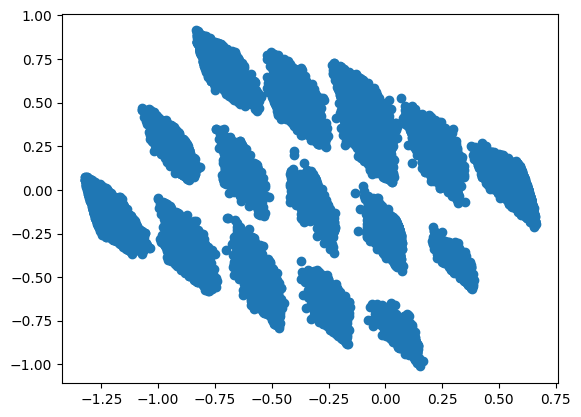

In [ ]:
# Use PCA to check the scatter plot of the data
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1])

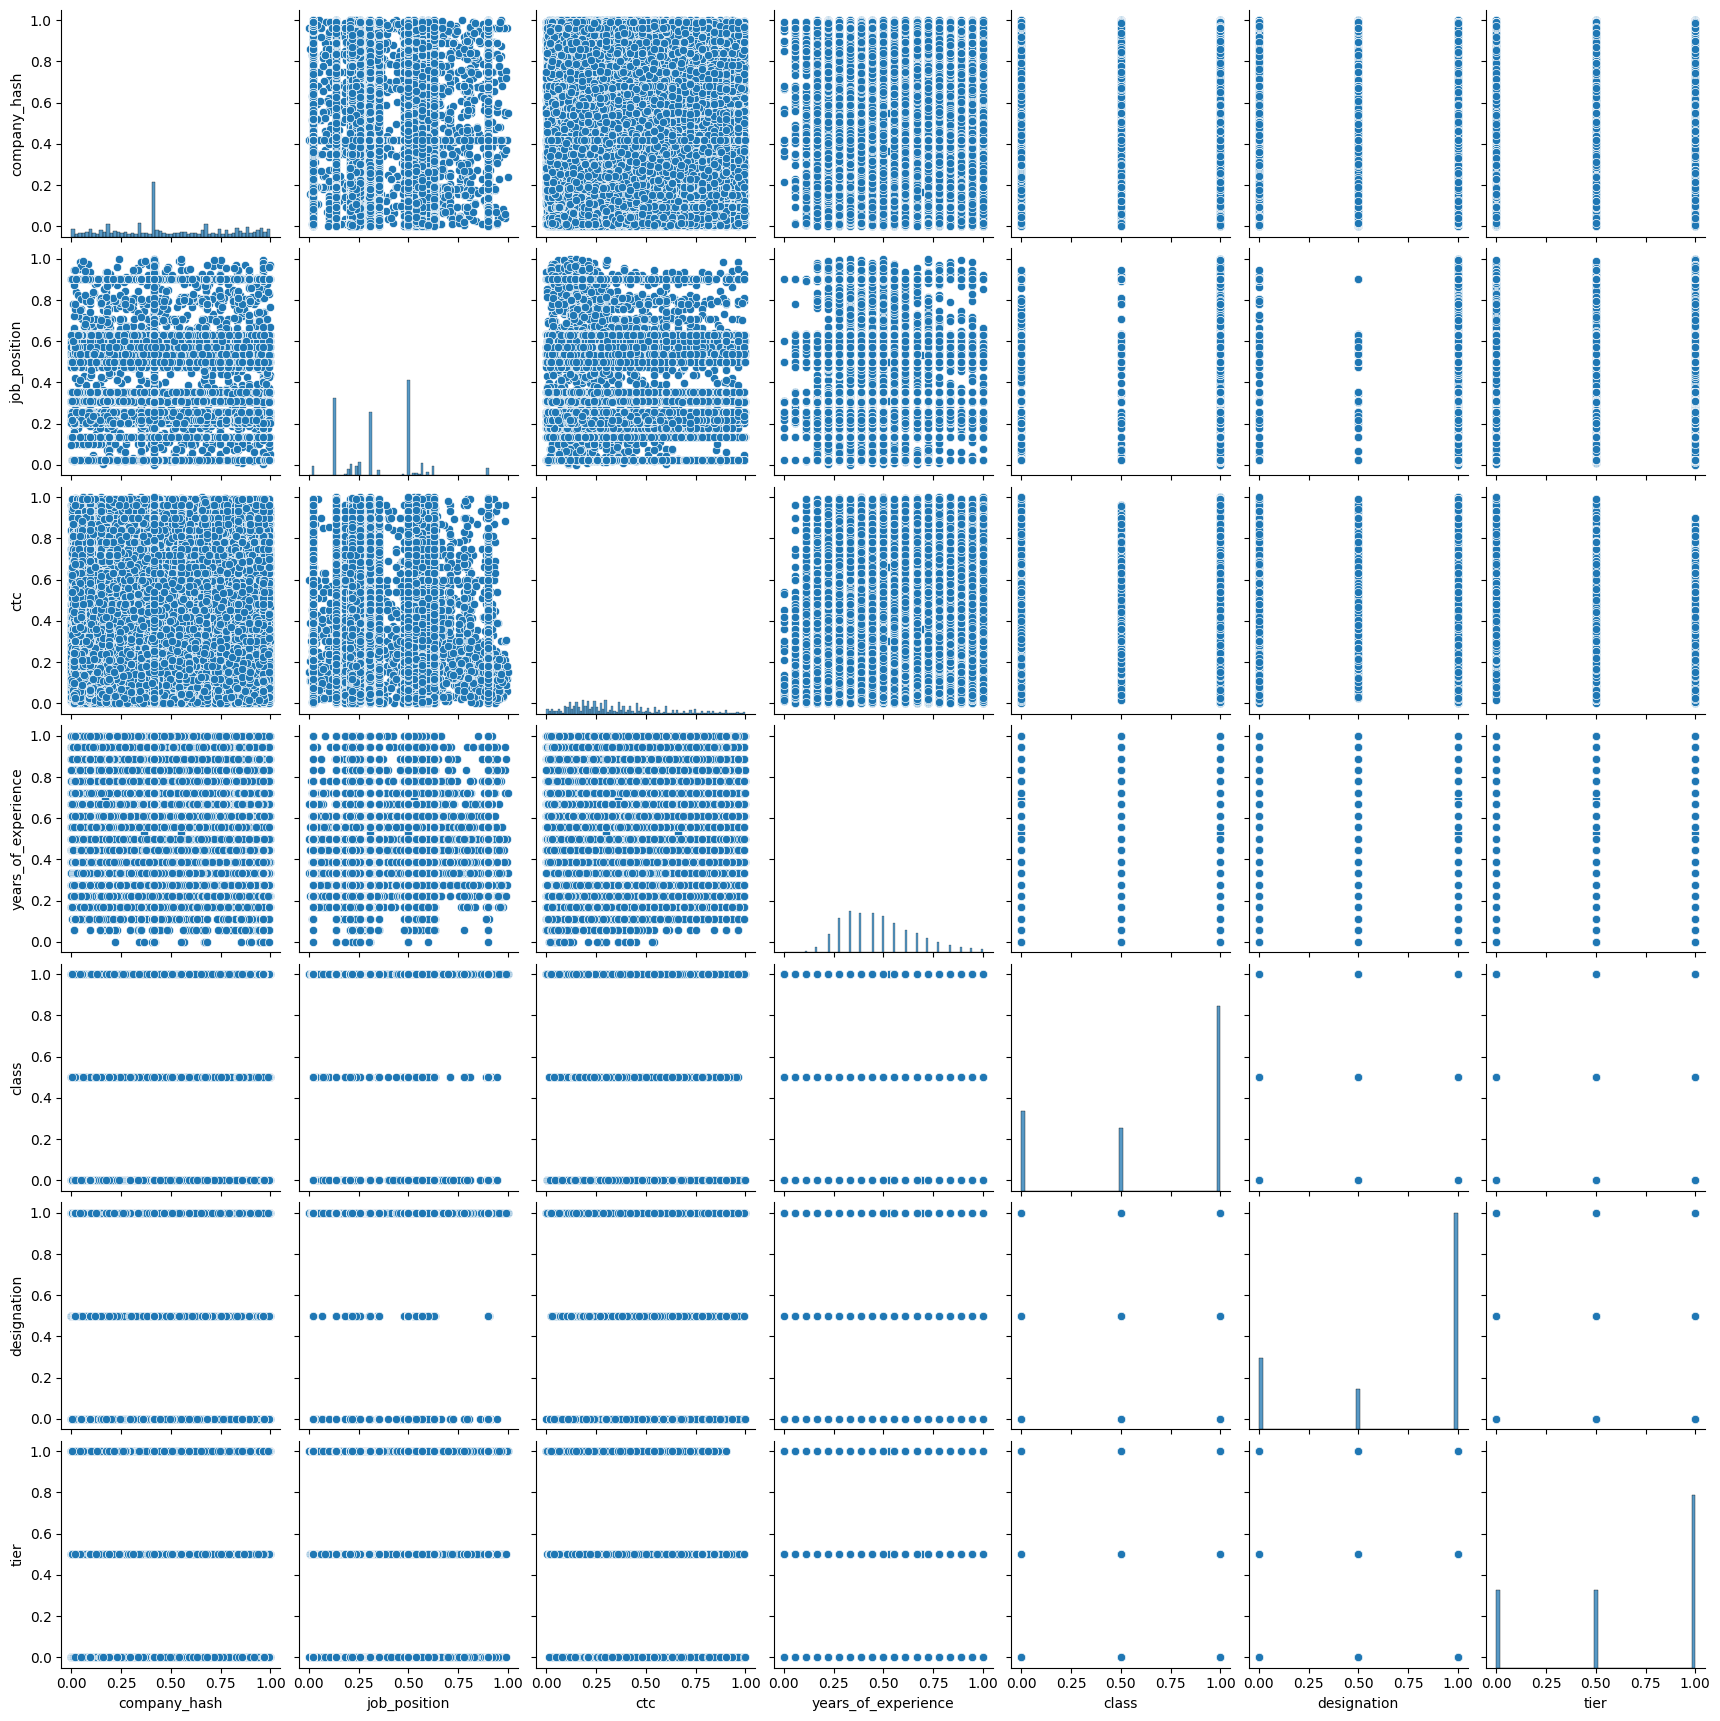

In [ ]:
sns.pairplot(X)

Find optimal K value to perform K-Means Clustering.

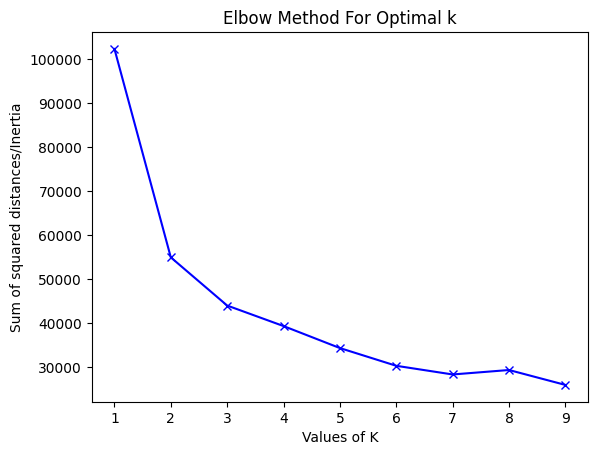

In [ ]:
Sum_of_squared_distances = []
K = range(1,10)
for num_clusters in K :
  kmeans = KMeans(n_clusters=num_clusters)
  kmeans.fit(X)
  Sum_of_squared_distances.append(kmeans.inertia_)
plt.plot(K,Sum_of_squared_distances,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Sum of squared distances/Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

Obeservation: Optimal value of k is 3 clusters from the elbow method

In [ ]:
kmeans = KMeans(n_clusters=3)

kmeans.fit(X)
print(kmeans.cluster_centers_)
print(kmeans.cluster_centers_.shape)

[[0.49843649 0.33327486 0.45935568 0.56393488 0.37183607 0.85847642
  0.31793836]
 [0.49798597 0.3420626  0.53380816 0.48543511 0.13959597 0.03988456
  0.18881935]
 [0.4975257  0.35402014 0.21931378 0.43750165 0.9780826  0.92910546
  0.95428051]]
(3, 7)


In [ ]:
X['k-m label']=kmeans.fit_predict(X)

In [ ]:
X

,company_hash,job_position,ctc,years_of_experience,class,designation,tier,k-m label
0,0.014838,0.499322,0.330330,0.444444,0.0,1.0,0.5,2
1,0.509239,0.308005,0.135134,0.333333,1.0,1.0,1.0,0
2,0.401176,0.135685,0.600600,0.500000,1.0,1.0,1.0,0
3,0.314390,0.135685,0.210210,0.388889,1.0,1.0,1.0,0
4,0.520997,0.308005,0.420420,0.388889,0.0,1.0,0.0,2
...,...,...,...,...,...,...,...,...
143626,0.297032,0.499322,0.675675,0.722222,0.0,0.0,0.0,1
143627,0.737122,0.499322,0.066066,0.888889,1.0,1.0,1.0,0
143628,0.214446,0.499322,0.150150,0.388889,1.0,1.0,1.0,0
143629,0.746081,0.499322,0.210210,0.166667,1.0,1.0,1.0,0


Questions:


In [ ]:
# What percentage users fall into largest cluster
X['k-m label'].value_counts(normalize=True)*100

,proportion
k-m label,
0,55.781830
2,22.747179
1,21.470992


**1)What percentage of users fall into largest cluster?**

Over 56% percentage of users fall into the largest cluster.

In [ ]:
Z=X.sample(frac=0.025)
Z.drop(columns=['k-m label'],inplace=True)
Z

,company_hash,job_position,ctc,years_of_experience,class,designation,tier
42150,0.061870,0.308005,0.165165,0.277778,1.0,1.0,1.0
83068,0.719485,0.499322,0.285285,0.388889,1.0,1.0,1.0
64324,0.085386,0.308005,0.264264,0.444444,1.0,1.0,1.0
25282,0.573908,0.499322,0.084084,0.444444,1.0,1.0,1.0
105431,0.416853,0.302578,0.396396,0.611111,0.0,0.5,0.5
...,...,...,...,...,...,...,...
34623,0.179171,0.559023,0.114114,0.500000,1.0,1.0,1.0
134191,0.798152,0.629579,0.258258,0.500000,0.0,1.0,1.0
67817,0.416853,0.135685,0.900901,0.333333,0.0,0.0,0.0
136089,0.968925,0.308005,0.300300,0.722222,1.0,1.0,1.0


In [ ]:
import sys
sys.setrecursionlimit(100000)

**Dendogram**

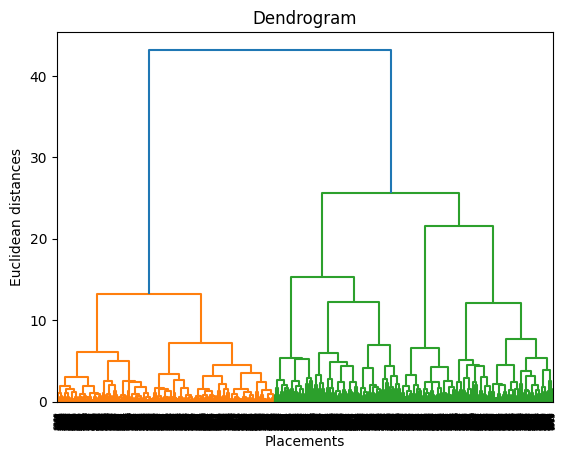

In [ ]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(Z, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Placements')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
# Agglomerative clustering

from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=3,  linkage='ward')
Z['Aglo-label']=cluster.fit_predict(Z)

In [ ]:
Z

,company_hash,job_position,ctc,years_of_experience,class,designation,tier,Aglo-label
42150,0.061870,0.308005,0.165165,0.277778,1.0,1.0,1.0,2
83068,0.719485,0.499322,0.285285,0.388889,1.0,1.0,1.0,2
64324,0.085386,0.308005,0.264264,0.444444,1.0,1.0,1.0,2
25282,0.573908,0.499322,0.084084,0.444444,1.0,1.0,1.0,2
105431,0.416853,0.302578,0.396396,0.611111,0.0,0.5,0.5,1
...,...,...,...,...,...,...,...,...
34623,0.179171,0.559023,0.114114,0.500000,1.0,1.0,1.0,2
134191,0.798152,0.629579,0.258258,0.500000,0.0,1.0,1.0,1
67817,0.416853,0.135685,0.900901,0.333333,0.0,0.0,0.0,0
136089,0.968925,0.308005,0.300300,0.722222,1.0,1.0,1.0,2


# **Insights and Recommendations**

**Insights from Manual Clustering:**

* Employee Segmentation: Manually clustering based on company_hash, job_position, and years_of_experience reveals distinct segments within the learner population. Creating designations (designation and class) provides a framework for categorizing employees based on their relative positions within their companies.
* Top Performers and Companies: Identifying the top earners (Tier 1) and companies (based on CTC) highlights potential areas for Scaler to focus on. This insight allows for targeted initiatives towards specific segments.
* Job Position Analysis: Analyzing the most frequent job positions associated with Tier 1 and Class 1 learners reveals the desired roles and skill sets within the learner community. This understanding can inform curriculum development and job placement support.

**Insights from Unsupervised Clustering**

* Clustering Tendency: Although the PCA and pairplot showed some limitations, they indicated a potential for clustering within the data. This suggests the possibility of grouping learners with similar characteristics.
* Optimal Clusters: The elbow method suggested 3 as the optimal number of clusters for K-Means. This provides a starting point for understanding different learner segments using unsupervised learning.
* Cluster Distribution: K-Means analysis revealed that over 56% of users belong to the largest cluster. Exploring the characteristics of this dominant cluster is crucial to understanding a significant portion of Scaler's learner base.
Hierarchical Structure: While performed on a sample, hierarchical clustering offered a visual depiction of the relationships between learners based on the selected features. This perspective can provide complementary insights to K-Means.
Okay, here are some recommendations for the business based on the analysis and modeling done in the code:

**Recommendations for Scaler:**

* Targeted Curriculum Development:
1. Focus on curriculum development for in-demand roles and skill sets identified through the analysis of top-tier learners and their preferred job positions. Specifically, job positions such as data scientist, software engineer, and data analyst emerged as popular among top earners. Tailor curriculum offerings to align with industry trends and equip learners for success in these desired roles.
2.  Address the skills gap by designing specialized courses that specifically address the needs of the industry. By focusing on industry-relevant skills and technologies, Scaler can enhance the employability of its learners and increase their chances of getting hired by top-tier companies.


* Job Placement Support:


1. Leverage the insights on top-tier companies and job positions to guide learners towards their career aspirations. Partner with companies that are known to offer high compensation and career growth opportunities.
2. Develop personalized job recommendations for learners based on their skills, experience, and cluster affiliations. By aligning learners with suitable positions, Scaler can improve their chances of finding fulfilling employment.
Strategic Partnerships:
3. Foster strategic partnerships with leading companies to create internship or job placement opportunities. Collaborate with industry leaders to ensure that Scaler's curriculum stays updated with the latest advancements and that graduates have access to relevant employment opportunities.
4. Build strong relationships with companies to ensure a steady pipeline of job opportunities for graduates. By maintaining strong connections with industry partners, Scaler can provide its learners with a competitive edge in the job market.


* Focus on Data Science Careers:

1. Given the prominence of data science roles among top earners, concentrate on offering comprehensive training and resources for data science-related positions. Offer specialized mentorship programs for aspiring data scientists.
2. Promote data science career paths by highlighting success stories and providing resources for skill development. Emphasize the growing demand for data scientists and provide learners with the necessary support to transition into this field.


* Community Building:
1. Facilitate a strong community among learners, alumni, and industry professionals to support networking and career development. Create online and offline opportunities for learners to connect with each other, industry experts, and potential employers.
2. Organize industry events and workshops to help learners gain exposure and stay updated with current trends. By creating a strong sense of community, Scaler can provide learners with a supportive network that can assist them throughout their careers.

In [ ]:












































































































#########

















































#########


























































































#####################








































